# Analisis Penentuan Lokasi Minimarket di Kota Dumai

- Dataset: Scrapping from MAPID API
- Location: Dumai, Riau
- By: Muhammad Rifqy

## Importing Library

In [1]:
import os
import geopandas as gpd
import requests
import pandas as pd
import matplotlib.pyplot as plt

## Scrapping API Dataset

Dalam analisis kali ini, dataset yang digunakan berasal dari MAPID API dengan rincian data yang digunakan sebagai berikut
- Data Demografi -> Data Socioeconomic Status Kota Dumai Tahun 2024
- Data Buffer Minimarket -> Data Lokasi Minimarket Kota Dumai Tahun 2024 -> Multi-Buffer Non Overlap
- Data Risiko Banjir -> Data Risiko Banjir Kota Dumai Tahun 2024
<p>Dalam prosesnya, dilakukan skoring dengan nilai kelas menggunakan Subjective Weighting <p>

In [2]:
# URL API
urls = {"Demografi": "https://geoserver.mapid.io/layers_new/get_layer?api_key=c3a63b03942e40d8b9a2b1511dcb035d&layer_id=68ada491b2fcc5561a30f59c&project_id=68ab1ecc6386ff356dc96202&limit=10000",
"Buffer Minimarket": "https://geoserver.mapid.io/layers_new/get_layer?api_key=c3a63b03942e40d8b9a2b1511dcb035d&layer_id=68adadfebdbfd0f39bffad47&project_id=68ab1ecc6386ff356dc96202&limit=10000",
"Risiko Banjir": "https://geoserver.mapid.io/layers_new/get_layer?api_key=c3a63b03942e40d8b9a2b1511dcb035d&layer_id=68ab2098b2fcc5561a2eaa16&project_id=68ab1ecc6386ff356dc96202&limit=10000"
}
# Fungsi untuk mengambil data dan menambahkan kolom skor
def get_data(url, layer_name):
    response = requests.get(url)
    if response.status_code == 200:
        geojson_data = response.json()
        gdf = gpd.GeoDataFrame.from_features(geojson_data['features'])

        # Menambahkan kolom skor berdasarkan layer
        # Menambahkan kolom skor berdasarkan layer
        if layer_name == "Demografi":
            if "SOCIOECONOMIC STATUS" in gdf.columns:
                print("Nilai unik di SOCIOECONOMIC STATUS:")
                print(gdf["SOCIOECONOMIC STATUS"].value_counts())
                print("Sample nilai:")
                print(gdf["SOCIOECONOMIC STATUS"].head())
                
                # Bersihkan data: hapus spasi ekstra dan ubah ke uppercase
                gdf["SOCIOECONOMIC STATUS"] = gdf["SOCIOECONOMIC STATUS"].astype(str).str.strip().str.upper()
                
                # Mapping yang lebih fleksibel
                mapping_demografi = {
                    "MENENGAH ATAS": 4,
                    "MENENGAH": 3, 
                    "MENENGAH BAWAH": 2,
                    "BAWAH": 1
                }
                
                gdf["SKOR_DEMOGRAFI"] = gdf["SOCIOECONOMIC STATUS"].map(mapping_demografi).fillna(0)
                
                print("Hasil mapping skor:")
                print(gdf["SKOR_DEMOGRAFI"].value_counts())
            else:
                print("Kolom 'SOCIOECONOMIC STATUS' tidak ditemukan!")
                gdf["SKOR_DEMOGRAFI"] = 0
                
        elif layer_name == "Buffer Minimarket":
            if "Kelas" in gdf.columns:
                print("Nilai unik di Kelas:")
                print(gdf["Kelas"].value_counts())
                
                # Bersihkan data
                gdf["Kelas"] = gdf["Kelas"].astype(str).str.strip().str.upper()
                
                mapping_buffer = {
                    "RENDAH": 3,
                    "SEDANG": 2,
                    "TINGGI": 1
                }
                
                gdf["SKOR_BUFFER"] = gdf["Kelas"].map(mapping_buffer).fillna(0)
                print("Hasil mapping skor:")
                print(gdf["SKOR_BUFFER"].value_counts())
            else:
                print("Kolom 'Kelas' tidak ditemukan!")
                gdf["SKOR_BUFFER"] = 0
                
        elif layer_name == "Risiko Banjir":
            if "KELAS_RISIKO" in gdf.columns:
                print("Nilai unik di KELAS_RISIKO:")
                print(gdf["KELAS_RISIKO"].value_counts())
                
                # Bersihkan data
                gdf["KELAS_RISIKO"] = gdf["KELAS_RISIKO"].astype(str).str.strip().str.upper()
                
                mapping_banjir = {
                    "RENDAH": 3,
                    "SEDANG": 2,
                    "TINGGI": 1
                }
                
                gdf["SKOR_BANJIR"] = gdf["KELAS_RISIKO"].map(mapping_banjir).fillna(0)
                print("Hasil mapping skor:")
                print(gdf["SKOR_BANJIR"].value_counts())
            else:
                print("Kolom 'KELAS_RISIKO' tidak ditemukan!")
                gdf["SKOR_BANJIR"] = 0

        return gdf
    return gpd.GeoDataFrame()

## Visualize Dataset

Visualisasi dilakukan untuk melihat apakah dataset terpanggil dengan baik.

Nilai unik di SOCIOECONOMIC STATUS:
SOCIOECONOMIC STATUS
Bawah             16
Menengah          10
Menengah Bawah     6
Menengah Atas      1
Name: count, dtype: int64
Sample nilai:
0    Bawah
1    Bawah
2    Bawah
3    Bawah
4    Bawah
Name: SOCIOECONOMIC STATUS, dtype: object
Hasil mapping skor:
SKOR_DEMOGRAFI
1    16
3    10
2     6
4     1
Name: count, dtype: int64
Nilai unik di Kelas:
Kelas
Sedang    4
Rendah    2
Tinggi    1
Name: count, dtype: int64
Hasil mapping skor:
SKOR_BUFFER
2    4
3    2
1    1
Name: count, dtype: int64
Nilai unik di KELAS_RISIKO:
KELAS_RISIKO
SEDANG    1754
RENDAH     879
TINGGI     739
Name: count, dtype: int64
Hasil mapping skor:
SKOR_BANJIR
2    1754
3     879
1     739
Name: count, dtype: int64


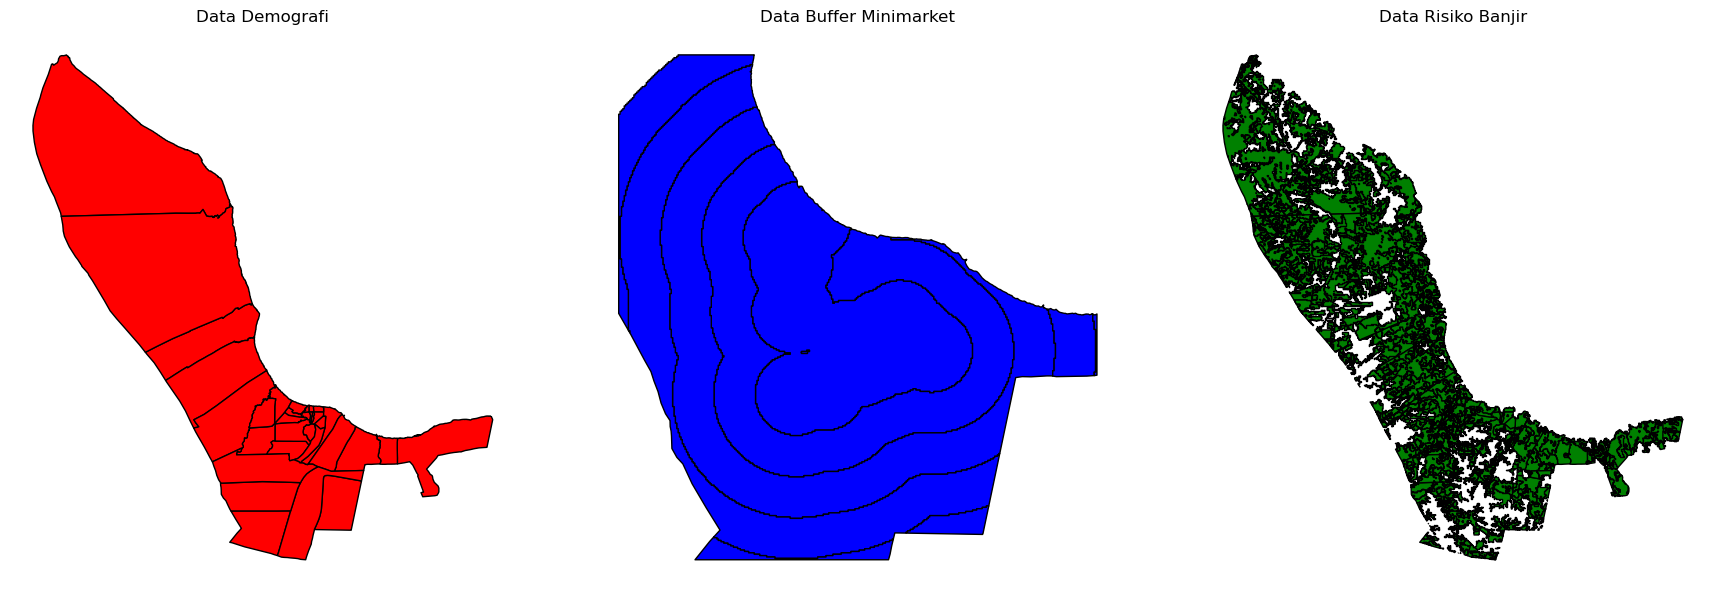

In [3]:
# Ambil data untuk semua layer
gdf_demografi = get_data(urls["Demografi"], "Demografi")
gdf_buffer = get_data(urls["Buffer Minimarket"], "Buffer Minimarket")
gdf_banjir = get_data(urls["Risiko Banjir"], "Risiko Banjir")

# Visualisasi data menggunakan matplotlib
def visualize_data(gdfs):
    fig, axes = plt.subplots(1, len(gdfs), figsize=(18, 6))
    color_map = ['red', 'blue', 'green']  # Warna berbeda untuk setiap layer
    
    for ax, (name, gdf), color in zip(axes, gdfs.items(), color_map):
        gdf.plot(ax=ax, color=color, edgecolor='black')
        ax.set_title(name)
        ax.set_axis_off()
    
    plt.tight_layout()
    plt.show()

# Menampilkan visualisasi dari ketiga GeoDataFrame
visualize_data({"Data Demografi": gdf_demografi, 
                "Data Buffer Minimarket": gdf_buffer, 
                "Data Risiko Banjir": gdf_banjir})

## Scoring Accumulation

Proses skoring total dilakukan dengan mengakumulasi 3 nilai skor dataset yang kemudian dikelaskan menjadi 4 kelas:
- Sangat rendah
- Rendah
- Sedang
- Tinggi

In [8]:
# Perbaikan untuk mengatasi nilai NULL
# Periksa dan perbaiki nilai NULL sebelum intersect
gdf_demografi['SKOR_DEMOGRAFI'] = gdf_demografi['SKOR_DEMOGRAFI'].fillna(0)
gdf_buffer['SKOR_BUFFER'] = gdf_buffer['SKOR_BUFFER'].fillna(0)
gdf_banjir['SKOR_BANJIR'] = gdf_banjir['SKOR_BANJIR'].fillna(0)

# Intersection - hanya area yang overlap di semua layer
intersection_gdf = gdf_demografi
if not gdf_buffer.empty:
    intersection_gdf = gpd.overlay(intersection_gdf, gdf_buffer, how='intersection', keep_geom_type=False)
    if not gdf_banjir.empty:
        intersection_gdf = gpd.overlay(intersection_gdf, gdf_banjir, how='intersection', keep_geom_type=False)

# Memperbaiki geometri yang tidak valid setelah intersection
intersection_gdf = intersection_gdf[intersection_gdf.is_valid]  # Menghapus geometri yang tidak valid
intersection_gdf['geometry'] = intersection_gdf['geometry'].apply(lambda x:
                                                                  x.make_valid() if not x.is_valid else x)

# Pastikan semua kolom skor ada dan tidak NULL
score_columns = ['SKOR_DEMOGRAFI', 'SKOR_BUFFER', 'SKOR_BANJIR']
for col in score_columns:
    if col not in intersection_gdf.columns:intersection_gdf[col] = 0
    intersection_gdf[col] = intersection_gdf[col].fillna(0)

    # Hitung skor total
    intersection_gdf['SKOR_TOTAL'] = (
        intersection_gdf['SKOR_DEMOGRAFI'] + 
        intersection_gdf['SKOR_BUFFER'] + 
        intersection_gdf['SKOR_BANJIR']
    )

    # Klasifikasi kesesuaian
    intersection_gdf['KESESUAIAN'] = pd.cut(
        intersection_gdf['SKOR_TOTAL'],
        bins=[0, 3, 6, 9, 12],  # Rentang yang disesuaikan
        labels=['SANGAT RENDAH', 'RENDAH', 'SEDANG', 'TINGGI'],
        include_lowest=True
    )


print(intersection_gdf[['SKOR_DEMOGRAFI', 'SKOR_BUFFER', 'SKOR_BANJIR','SKOR_TOTAL', 'KESESUAIAN']].head(10))

   SKOR_DEMOGRAFI  SKOR_BUFFER  SKOR_BANJIR  SKOR_TOTAL KESESUAIAN
0               1            3            1           5     RENDAH
1               1            3            1           5     RENDAH
2               1            3            1           5     RENDAH
3               1            3            1           5     RENDAH
4               1            3            1           5     RENDAH
5               1            3            1           5     RENDAH
6               1            2            1           4     RENDAH
7               1            2            1           4     RENDAH
8               1            3            2           6     RENDAH
9               1            3            2           6     RENDAH


## Filtering - Validating Polygon

Filtering dan Validating poligon dilakukan untuk membersihkan poligon-poligon yang tidak benilai (NaN) agar data yang teranalisis adalah data yang valid.

In [82]:
# Filter hanya geometri Polygon dan MultiPolygon
intersection_gdf_polygons = intersection_gdf[intersection_gdf.geometry.type.isin(['Polygon', 'MultiPolygon'])]

# Perbaiki geometri yang tidak valid
intersection_gdf_polygons['geometry'] = intersection_gdf_polygons['geometry'].apply(lambda x: x.make_valid() if not x.is_valid else x)

# Simpan Data Variabel
# gdf_demografi.to_file(os.path.join(output_dir, "demografi.geojson"), driver='GeoJSON')
# gdf_densitas.to_file(os.path.join(output_dir, "densitas_minimarket.geojson"), driver='GeoJSON')
# gdf_banjir.to_file(os.path.join(output_dir, "risiko_banjir.geojson"), driver='GeoJSON')

# Konversi kolom categorical ke string untuk kompatibilitas GeoJSON
intersection_gdf_polygons_copy = intersection_gdf_polygons.copy()
for col in intersection_gdf_polygons_copy.columns:
    if intersection_gdf_polygons_copy[col].dtype.name == 'category':
        intersection_gdf_polygons_copy[col] = intersection_gdf_polygons_copy[col].astype(str)

# Simpan hasil intersection yang telah diperbaiki ke GeoJSON
intersection_gdf_polygons_copy.to_file("Hasil_Intersect_4.geojson", driver='GeoJSON')

print(f"Data berhasil disimpan di:")
print("Semua file geojson telah berhasil disimpan.")

C:\Users\ACER\anaconda3\lib\site-packages\geopandas\geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Data berhasil disimpan di:
Semua file geojson telah berhasil disimpan.
